In [13]:
lines = open("trening.txt").readlines()

In [14]:
training_lines = []
for line in lines:
    if "Full Dataset" in line:
        training_lines.append(line)

In [20]:
import re
results = [[],[],[]]
for line in training_lines:
    match = re.search(r'\[Ep (\d+)\] Train Loss: ([\d.]+) Acc: ([\d.]+)', line)
    if match:
        epoch = int(match.group(1))
        loss = float(match.group(2))
        accuracy = float(match.group(3))
        results[0].append(epoch)
        results[1].append(loss)
        results[2].append(accuracy)
        print(f"{line}")
        print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {accuracy}")
    

Full Dataset [Ep 1] Train Loss: 0.3234 Acc: 0.8524

Epoch: 1, Loss: 0.3234, Accuracy: 0.8524
Full Dataset [Ep 2] Train Loss: 0.1322 Acc: 0.9493

Epoch: 2, Loss: 0.1322, Accuracy: 0.9493
Full Dataset [Ep 3] Train Loss: 0.0829 Acc: 0.9684

Epoch: 3, Loss: 0.0829, Accuracy: 0.9684
Full Dataset [Ep 4] Train Loss: 0.0647 Acc: 0.9746

Epoch: 4, Loss: 0.0647, Accuracy: 0.9746
Full Dataset [Ep 5] Train Loss: 0.0505 Acc: 0.9827

Epoch: 5, Loss: 0.0505, Accuracy: 0.9827
Full Dataset [Ep 6] Train Loss: 0.0419 Acc: 0.9839

Epoch: 6, Loss: 0.0419, Accuracy: 0.9839
Full Dataset [Ep 7] Train Loss: 0.0348 Acc: 0.9890

Epoch: 7, Loss: 0.0348, Accuracy: 0.989
Full Dataset [Ep 8] Train Loss: 0.0330 Acc: 0.9889

Epoch: 8, Loss: 0.033, Accuracy: 0.9889
Full Dataset [Ep 9] Train Loss: 0.0249 Acc: 0.9909

Epoch: 9, Loss: 0.0249, Accuracy: 0.9909
Full Dataset [Ep 10] Train Loss: 0.0254 Acc: 0.9908

Epoch: 10, Loss: 0.0254, Accuracy: 0.9908
Full Dataset [Ep 11] Train Loss: 0.0209 Acc: 0.9932

Epoch: 11, Loss: 

In [23]:
print(results[2])

[0.8524, 0.9493, 0.9684, 0.9746, 0.9827, 0.9839, 0.989, 0.9889, 0.9909, 0.9908, 0.9932, 0.9916, 0.9938, 0.9943, 0.9946, 0.9938, 0.9948, 0.9951, 0.9943, 0.9958, 0.996, 0.9957, 0.9955, 0.996, 0.9968, 0.996, 0.9967, 0.9965, 0.9967, 0.9969, 0.9971, 0.9978, 0.9975, 0.9964, 0.9978, 0.9975, 0.9973, 0.9971, 0.998, 0.9976, 0.998, 0.9972, 0.9972, 0.9986, 0.9979, 0.9983, 0.9978, 0.9984, 0.9986, 0.9984]


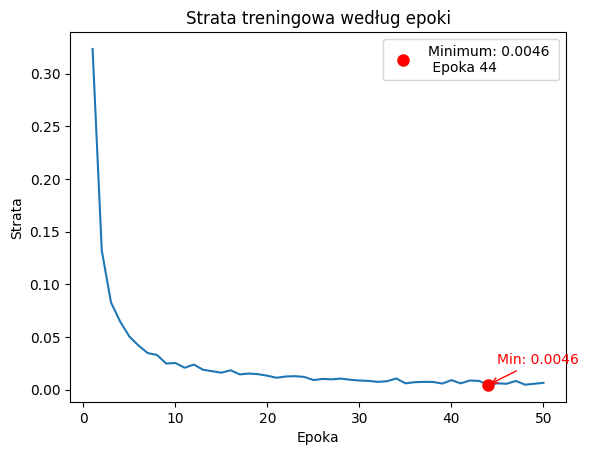

In [39]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plot = sns.lineplot(x=results[0], y=results[1])
plot.set_title("Strata treningowa według epoki")
plot.set_xlabel("Epoka")
plot.set_ylabel("Strata")


# Mark the lowest point
min_idx = np.argmin(results[1])
min_x = results[0][min_idx]
min_y = results[1][min_idx]

# Add a marker at the lowest point
plot.plot(min_x, min_y, 'ro', markersize=8, label=f'Minimum: {min_y:.4f} \n Epoka {min_x}')

# Optional: Add annotation with arrow
plot.annotate(f'Min: {min_y:.4f}', 
             xy=(min_x, min_y), 
             xytext=(min_x + 1, min_y + 0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10,
             color='red')

plot.legend()
plt.savefig('strataepoka.png')

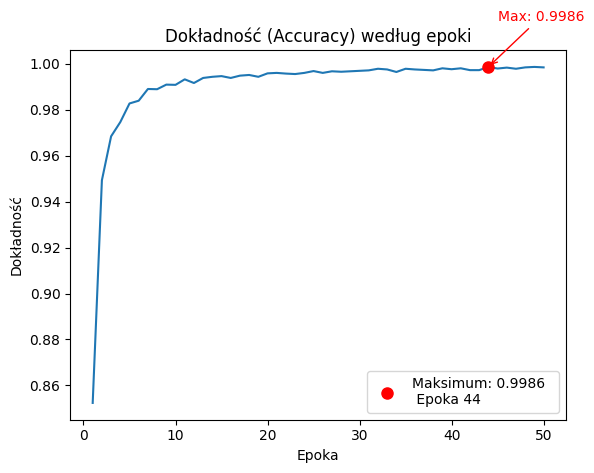

In [40]:
import seaborn as sns
import numpy as np
plot = sns.lineplot(x=results[0], y=results[2])
plot.set_title("Dokładność (Accuracy) według epoki")
plot.set_xlabel("Epoka")
plot.set_ylabel("Dokładność")

# 
# Mark the lowest point
max_idx = np.argmax(results[2])
max_x = results[0][max_idx]
max_y = results[2][max_idx]

# Add a marker at the lowest point
plot.plot(max_x, max_y, 'ro', markersize=8, label=f'Maksimum: {max_y:.4f}  \n Epoka {min_x}')

# Optional: Add annotation with arrow
plot.annotate(f'Max: {max_y:.4f}', 
             xy=(max_x, max_y), 
             xytext=(max_x + 1, max_y + 0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10,
             color='red')

plot.legend()
plt.savefig('Dokładnoscaepoka.png')